In [1]:
import sys
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler
import seaborn as sns

this_path = Path(__file__) if '__file__' in globals() else Path("<unknown>.ipynb").resolve()
work_path = next((p for p in this_path.parents if p.name == "research"), None)
tools_path = work_path / Path("../torch-tools")
sys.path.append(str(tools_path))

from exp_manager import ExpManager, cat_results
import pl_utils


In [2]:
pl_utils.Config()

p_path = this_path.parent
df_base = cat_results([p_path / "exp_opt*"]).filter(pl.col("epochs") == pl.col("epoch").list.last())
df_stats = df_base.pipe(pl_utils.snapshot)

print(df_base.columns)
print(df_base)


['exp_name', 'run_id', 'model_arc', 'train_dataset', 'val_dataset', 'num_classes', 'train_trans', 'val_trans', 'train_ndata', 'val_ndata', 'epochs', 'max_lr', 'wd', 'batch_size', 'iters/epoch', 'iters', 'target_steps', 'ndata_per_class', 'fils', 'ensembles', 'base_fils', 'num_params', 'criterion', 'optimizer', 'scheduler', 'step', 'epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'param_norm', 'grad_norm', 'param_norm_layer', 'grad_norm_layer', 'g2w_ratio', 'dur_total_core', 'dur_train_core', 'dur_dl_train']
shape: (371, 39)
┌──────────────┬────────┬───────────────────────────┬────────────────┬──────────────┬─────────────┬───────────────────────────┬───────────────────────────┬─────────────┬───────────┬────────┬────────┬──────────┬────────────┬─────────────┬───────┬──────────────┬─────────────────┬──────┬───────────┬───────────┬────────────┬──────────────────┬───────────┬───────────────────┬────────────────┬────────────────┬───────────────────────────┬─────────────────────────

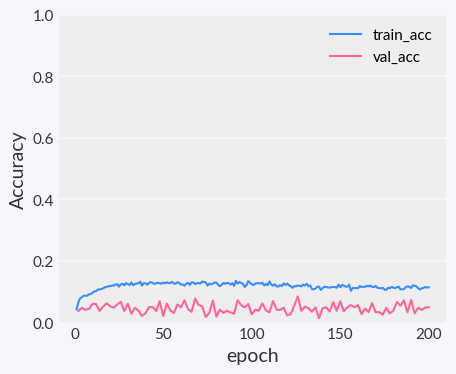

In [3]:
df = df_base

run_d = df.row(0, named=True)
x_col = "epoch"
y_cols = ["train_acc", "val_acc"]

plt.rcParams['font.family'] = ['Lato']
modern_colors = ['#368DFF', '#FF6495', '#3DD598', '#FFC542', '#8C52FF', '#FF6E4A']
plt.rcParams['axes.prop_cycle'] = cycler(color=modern_colors)

fig, ax = plt.subplots(figsize=(5, 4))
# fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), squeeze=False)
fig.patch.set_facecolor('#F4F7FC')
ax.set_facecolor('#EEEEEE')
for y_col in y_cols:
    x = run_d[x_col]
    y = run_d[y_col]
    x, y = zip(*[(xi, yi) for xi, yi in zip(x, y) if yi is not None]) # Noneの値を除外
    ax.plot(x, y, label=y_col, linewidth=1.5)

legend = ax.legend(fontsize=11, frameon=False)

ax.set_ylim([0, 1])
ax.set_xlabel(x_col, fontsize=14, color='#333333')
ax.set_ylabel("Accuracy", fontsize=14, color='#333333')
ax.grid(axis='y', linestyle='-', color='#FFFFFF', alpha=0.5, linewidth=1.2) # グリッドを薄い白ベースで太く

ax.tick_params(axis='both', which='major', labelsize=11, colors='#333333')
ax.tick_params(axis='both', which='both', length=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# ax.spines['left'].set_color('#D3D3D3')      # 色を薄い灰色に
# ax.spines['bottom'].set_color('#D3D3D3')    # 色を薄い灰色に
# ax.spines['left'].set_linewidth(0.6)       # 線の太さを細く
# ax.spines['bottom'].set_linewidth(0.6)     # 線の太さを細く

# ax.set_title(f"nyaaaaa", fontsize=12)
plt.show()


In [4]:
df = df_base
df = df.filter(pl.col("optimizer") == "SGD")
# df = df.filter(pl.col("train_ndata") == 5000)
# df = df.filter(pl.col("fils") == 2)

# df = df.pivot(values="val_acc", index)

print(df_base.columns)
with pl_utils.Config():
    print(df)
    # print(df_stats)
    

['exp_name', 'run_id', 'model_arc', 'train_dataset', 'val_dataset', 'num_classes', 'train_trans', 'val_trans', 'train_ndata', 'val_ndata', 'epochs', 'max_lr', 'wd', 'batch_size', 'iters/epoch', 'iters', 'target_steps', 'ndata_per_class', 'fils', 'ensembles', 'base_fils', 'num_params', 'criterion', 'optimizer', 'scheduler', 'step', 'epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'param_norm', 'grad_norm', 'param_norm_layer', 'grad_norm_layer', 'g2w_ratio', 'dur_total_core', 'dur_train_core', 'dur_dl_train']
shape: (200, 39)
┌──────────────┬────────┬───────────────────────────┬────────────────┬──────────────┬─────────────┬───────────────────────────┬───────────────────────────┬─────────────┬───────────┬────────┬────────┬───────┬────────────┬─────────────┬───────┬──────────────┬─────────────────┬──────┬───────────┬───────────┬────────────┬──────────────────┬───────────┬───────────────────┬────────────────┬────────────────┬───────────────────────────┬───────────────────────────┬